# Malaria Diagnosis: ResNet50 Transfer Learning Model
Kevine UWISANGA
Transfer Learning Model (ResNet50)

This notebook covers, for the ResNet50 model only:
- Data loading & pipeline (NIH/NLM malaria cell dataset, 27,558 images)
- 8 logged experiments (progression from frozen baseline to fine-tuned), TensorBoard tracking
- Per-experiment metrics table (accuracy, precision, recall, F1, ROC-AUC, sensitivity, specificity)
- Required visualizations for the final model (accuracy curve, loss curve, confusion matrix, ROC curve)
- Error analysis
- Grad-CAM explainability (1 correct-infected, 1 correct-uninfected, 1 incorrect example)
- Packaging the TensorBoard logs for the report appendix


In [ ]:
!pip install -q "protobuf>=6.31.1,<7"
!pip install -q "protobuf>=6.31.1,<7" importlib_resources

import os, io, json, random, datetime, zipfile, textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_datasets as tfds
from sklearn.metrics import (confusion_matrix, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve, accuracy_score)

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

print("TF version:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("GPUs:", gpus if gpus else "None found — training will be slow, use Colab GPU runtime.")

IMG_SIZE = (224, 224)   # ResNet50's native input size
BATCH_SIZE_DEFAULT = 32
AUTOTUNE = tf.data.AUTOTUNE
LOG_ROOT = "logs/fit"
os.makedirs(LOG_ROOT, exist_ok=True)

TF version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 1. Data loading & pipeline

Uses the built-in `tfds` `malaria` dataset; this *is* the NIH/NLM 27,558-image parasitized/uninfected cell set the assignment references, so you don't need to download/unzip it manually. It ships as a single `train` split, so we split it ourselves: **80% train / 10% validation / 10% test**, stratified by class so every split holds an exact 50/50 parasitized/uninfected balance.

In [ ]:
(ds_full,), ds_info = tfds.load(
    "malaria",
    split=["train"],
    as_supervised=True,
    with_info=True,
    shuffle_files=True,
)

n_total = ds_info.splits["train"].num_examples
print("Total examples:", n_total)
print("Label names:", ds_info.features["label"].names)  # ['parasitized', 'uninfected']

ds_full = ds_full.shuffle(n_total, seed=SEED, reshuffle_each_iteration=False)

# Stratified 80/10/10 split: separate by class first so each split holds an
# exact 50/50 parasitized/uninfected balance, rather than relying on the
# dataset's natural balance surviving a single random shuffle-and-slice.
def is_class(c):
    return lambda img, lab: tf.equal(lab, c)

ds_c0 = ds_full.filter(is_class(0))  # parasitized
ds_c1 = ds_full.filter(is_class(1))  # uninfected

# The malaria dataset is exactly balanced (13,779 per class). Using that directly avoids two full
# passes over the dataset just to count it, which was one of the slow/freezing steps.
n_c0 = n_c1 = n_total // 2
print("Per-class counts — parasitized:", n_c0, " uninfected:", n_c1)

def split_class(ds, n, train_frac=0.80, val_frac=0.10, test_frac=0.10):
    """80/10/10 split, each fraction taken directly out of this class's total n."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-9
    n_train = int(round(train_frac * n))
    n_val   = int(round(val_frac * n))
    n_test  = n - n_train - n_val  # remainder, avoids rounding drift
    ds_train = ds.take(n_train)
    ds_val   = ds.skip(n_train).take(n_val)
    ds_test  = ds.skip(n_train + n_val)
    return ds_train, ds_val, ds_test, n_train, n_val, n_test

ds_c0_train, ds_c0_val, ds_c0_test, n0_tr, n0_va, n0_te = split_class(ds_c0, n_c0)
ds_c1_train, ds_c1_val, ds_c1_test, n1_tr, n1_va, n1_te = split_class(ds_c1, n_c1)

shuffle_seed_train, shuffle_seed_val, shuffle_seed_test = SEED + 1, SEED + 2, SEED + 3
ds_train_raw = ds_c0_train.concatenate(ds_c1_train).shuffle(n0_tr + n1_tr, seed=shuffle_seed_train, reshuffle_each_iteration=False).cache()
ds_val_raw   = ds_c0_val.concatenate(ds_c1_val).shuffle(max(n0_va + n1_va, 1), seed=shuffle_seed_val, reshuffle_each_iteration=False).cache()
ds_test_raw  = ds_c0_test.concatenate(ds_c1_test).shuffle(n0_te + n1_te, seed=shuffle_seed_test, reshuffle_each_iteration=False).cache()

n_train, n_val, n_test = n0_tr + n1_tr, n0_va + n1_va, n0_te + n1_te
print(f"train/val/test sizes: {n_train}/{n_val}/{n_test}  "
      f"(train = {n_train/n_total:.0%}, val = {n_val/n_total:.0%}, test = {n_test/n_total:.0%} of total)")
print(f"Class balance — train: {n0_tr}/{n1_tr}, val: {n0_va}/{n1_va}, test: {n0_te}/{n1_te} (parasitized/uninfected)")

Total examples: 27558
Label names: ['parasitized', 'uninfected']
Per-class counts — parasitized: 13779  uninfected: 13779
train/val/test sizes: 22046/2756/2756  (train = 80%, val = 10%, test = 10% of total)
Class balance — train: 11023/11023, val: 1378/1378, test: 1378/1378 (parasitized/uninfected)


In [ ]:
# Preprocessing: resize + ResNet50's own preprocess_input (caffe-style channel scaling)
resnet_preprocess = tf.keras.applications.resnet50.preprocess_input

def preprocess(image, label):
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    image = resnet_preprocess(image)
    label = tf.cast(label, tf.float32)
    return image, label

# Augmentation block
augment_layers = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.08),
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomContrast(0.1),
], name="augmentation")

def make_dataset(ds_raw, batch_size, training=False, augment=False, shuffle_buf=2000):
    ds = ds_raw
    if training and shuffle_buf:
        ds = ds.shuffle(shuffle_buf, seed=SEED)   # shuffle the small raw images, not 224px float32 ones (saves ~1GB RAM)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    if training and augment:
        ds = ds.map(lambda x, y: (augment_layers(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)

# Fixed val/test sets for fair comparison across experiments.
ds_val   = make_dataset(ds_val_raw, BATCH_SIZE_DEFAULT, training=False)
ds_test  = make_dataset(ds_test_raw, BATCH_SIZE_DEFAULT, training=False)


## 2. Model builder & training utilities

`build_resnet50_model(cfg)` builds a fresh ResNet50 (ImageNet weights, no top) each time, with the head, freeze depth, dropout and L2 controlled by the experiment config; this is what lets the 8 runs below be completely different experiments rather than reruns.

In [ ]:
def build_resnet50_model(cfg):
    base = tf.keras.applications.ResNet50(
        include_top=False, weights="imagenet", input_shape=IMG_SIZE + (3,)
    )

    unfreeze_last_n = cfg.get("unfreeze_last_n", 0)
    if unfreeze_last_n == 0:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:-unfreeze_last_n]:
            layer.trainable = False

        for layer in base.layers[-unfreeze_last_n:]:
            if isinstance(layer, tf.keras.layers.BatchNormalization):
                layer.trainable = False

    reg = tf.keras.regularizers.l2(cfg.get("l2", 0.0)) if cfg.get("l2", 0.0) > 0 else None

    inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
    x = base(inputs, training=False if unfreeze_last_n == 0 else None)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=reg)(x)
    if cfg.get("dropout", 0.0) > 0:
        x = tf.keras.layers.Dropout(cfg["dropout"])(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs, name=cfg["run_name"])
    return model, base


def make_optimizer(cfg):
    lr = cfg.get("lr", 1e-3)
    kind = cfg.get("optimizer", "adam")
    if kind == "adam":
        return tf.keras.optimizers.Adam(learning_rate=lr)
    if kind == "sgd":
        return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
    raise ValueError(f"Unknown optimizer {kind}")


def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])  # 0=parasitized, 1=uninfected
    tn, fp, fn, tp = cm.ravel()
    # Positive class for "infection detection" purposes is 'parasitized' (label 0).
    sensitivity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # recall on parasitized
    specificity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # recall on uninfected
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, pos_label=0, zero_division=0),
        "recall": recall_score(y_true, y_pred, pos_label=0, zero_division=0),
        "f1": f1_score(y_true, y_pred, pos_label=0, zero_division=0),
        "roc_auc": roc_auc_score(1 - y_true, 1 - y_prob),  # AUC w.r.t. 'parasitized' as positive
        "sensitivity": sensitivity,
        "specificity": specificity,
        "confusion_matrix": cm,
    }


def train_and_evaluate(cfg, epochs_override=None):
    tf.keras.backend.clear_session()
    ds_train = make_dataset(
        ds_train_raw, cfg.get("batch_size", BATCH_SIZE_DEFAULT),
        training=True, augment=cfg.get("augment", False)
    )
    ds_val_local = make_dataset(ds_val_raw, cfg.get("batch_size", BATCH_SIZE_DEFAULT), training=False)

    model, base = build_resnet50_model(cfg)
    model.compile(
        optimizer=make_optimizer(cfg),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )

    logdir = os.path.join(LOG_ROOT, cfg["run_name"])
    tb_cb = tf.keras.callbacks.TensorBoard(log_dir=logdir, histogram_freq=0)
    es_cb = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    )

    # Log the run's hyperparameters as a text summary so they show up in TensorBoard alongside the scalars.
    with tf.summary.create_file_writer(logdir).as_default():
        tf.summary.text("config", json.dumps(cfg, default=str), step=0)

    epochs = epochs_override or cfg.get("epochs", 15)
    history = model.fit(
        ds_train, validation_data=ds_val_local, epochs=epochs,
        callbacks=[tb_cb, es_cb], verbose=2,
    )

    y_true, y_prob = [], []
    for x, y in ds_test:
        p = model.predict(x, verbose=0).ravel()
        y_true.append(y.numpy()); y_prob.append(p)
    y_true = np.concatenate(y_true); y_prob = np.concatenate(y_prob)

    metrics = compute_metrics(y_true, y_prob)
    with tf.summary.create_file_writer(logdir).as_default():
        for k in ["accuracy", "precision", "recall", "f1", "roc_auc", "sensitivity", "specificity"]:
            tf.summary.scalar(f"test_{k}", metrics[k], step=epochs)

    return {
        "cfg": cfg, "model": model, "history": history.history,
        "metrics": metrics, "y_true": y_true, "y_prob": y_prob,
        "logdir": logdir,
    }


## 3. Experiments (8 runs — meets the 7+ requirement)

Progression: frozen baseline → learning-rate tuning → augmentation → regularization → shallow fine-tuning → deeper fine-tuning at a lower LR → batch-size check → optimizer comparison. Naming follows `resnet50_exp_NN_description`.

In [ ]:
experiment_configs = {
    "resnet50_exp_01_baseline_frozen": dict(
        run_name="resnet50_exp_01_baseline_frozen",
        unfreeze_last_n=0, optimizer="adam", lr=1e-3, batch_size=32,
        augment=False, dropout=0.0, l2=0.0, epochs=15),

    "resnet50_exp_02_lr_1e-4": dict(
        run_name="resnet50_exp_02_lr_1e-4",
        unfreeze_last_n=0, optimizer="adam", lr=1e-4, batch_size=32,
        augment=False, dropout=0.0, l2=0.0, epochs=15),

    "resnet50_exp_03_augmentation": dict(
        run_name="resnet50_exp_03_augmentation",
        unfreeze_last_n=0, optimizer="adam", lr=1e-4, batch_size=32,
        augment=True, dropout=0.0, l2=0.0, epochs=15),

    "resnet50_exp_04_dropout_l2": dict(
        run_name="resnet50_exp_04_dropout_l2",
        unfreeze_last_n=0, optimizer="adam", lr=1e-4, batch_size=32,
        augment=True, dropout=0.3, l2=1e-4, epochs=15),

    "resnet50_exp_05_unfreeze_last20": dict(
        run_name="resnet50_exp_05_unfreeze_last20",
        unfreeze_last_n=20, optimizer="adam", lr=1e-5, batch_size=32,
        augment=True, dropout=0.3, l2=1e-4, epochs=20),

    "resnet50_exp_06_unfreeze_last50_lr_5e-6": dict(
        run_name="resnet50_exp_06_unfreeze_last50_lr_5e-6",
        unfreeze_last_n=50, optimizer="adam", lr=5e-6, batch_size=32,
        augment=True, dropout=0.3, l2=1e-4, epochs=20),

    "resnet50_exp_07_batch_size_64": dict(
        run_name="resnet50_exp_07_batch_size_64",
        unfreeze_last_n=20, optimizer="adam", lr=1e-5, batch_size=64,
        augment=True, dropout=0.3, l2=1e-4, epochs=20),

    "resnet50_exp_08_sgd_momentum": dict(
        run_name="resnet50_exp_08_sgd_momentum",
        unfreeze_last_n=20, optimizer="sgd", lr=1e-3, batch_size=32,
        augment=True, dropout=0.3, l2=1e-4, epochs=20),
}

import gc

results = {}
os.makedirs("saved_models", exist_ok=True)
METRICS_CSV = "resnet50_experiments_metrics.csv"

def run_experiment(run_key):
    """Run one experiment by key, store it in `results`, persist its metrics and
    trained model to disk, then free the model from memory so RAM doesn't climb
    across successive runs."""
    cfg = experiment_configs[run_key]
    print("="*80); print("Running:", cfg["run_name"]); print("="*80)
    r = train_and_evaluate(cfg)

    row = {"run_name": run_key, **{k: v for k, v in r["metrics"].items() if k != "confusion_matrix"}}
    existing = pd.read_csv(METRICS_CSV) if os.path.exists(METRICS_CSV) else pd.DataFrame()
    existing = existing[existing.get("run_name", pd.Series(dtype=str)) != run_key]  # replace if rerun
    pd.concat([existing, pd.DataFrame([row])], ignore_index=True).to_csv(METRICS_CSV, index=False)

    r["model"].save(f"saved_models/{run_key}.keras")
    print(f"Saved metrics row to {METRICS_CSV} and model to saved_models/{run_key}.keras")

    r["model"] = None
    results[run_key] = r
    gc.collect()
    tf.keras.backend.clear_session()
    return r

In [ ]:
run_experiment("resnet50_exp_01_baseline_frozen")

Running: resnet50_exp_01_baseline_frozen
Epoch 1/15
689/689 - 116s - 168ms/step - accuracy: 0.9141 - auc: 0.9708 - loss: 0.2177 - val_accuracy: 0.9115 - val_auc: 0.9836 - val_loss: 0.2192
Epoch 2/15
689/689 - 101s - 147ms/step - accuracy: 0.9374 - auc: 0.9827 - loss: 0.1649 - val_accuracy: 0.9361 - val_auc: 0.9862 - val_loss: 0.1645
Epoch 3/15
689/689 - 67s - 98ms/step - accuracy: 0.9450 - auc: 0.9854 - loss: 0.1498 - val_accuracy: 0.9303 - val_auc: 0.9873 - val_loss: 0.1717
Epoch 4/15
689/689 - 68s - 98ms/step - accuracy: 0.9418 - auc: 0.9856 - loss: 0.1499 - val_accuracy: 0.9510 - val_auc: 0.9888 - val_loss: 0.1342
Epoch 5/15
689/689 - 82s - 119ms/step - accuracy: 0.9479 - auc: 0.9875 - loss: 0.1384 - val_accuracy: 0.9445 - val_auc: 0.9878 - val_loss: 0.1403
Epoch 6/15
689/689 - 68s - 98ms/step - accuracy: 0.9511 - auc: 0.9889 - loss: 0.1304 - val_accuracy: 0.9481 - val_auc: 0.9893 - val_loss: 0.1366
Epoch 7/15
689/689 - 68s - 98ms/step - accuracy: 0.9532 - auc: 0.9896 - loss: 0.1252

{'cfg': {'run_name': 'resnet50_exp_01_baseline_frozen',
  'unfreeze_last_n': 0,
  'optimizer': 'adam',
  'lr': 0.001,
  'batch_size': 32,
  'augment': False,
  'dropout': 0.0,
  'l2': 0.0,
  'epochs': 15},
 'model': None,
 'history': {'accuracy': [0.9141340851783752,
   0.9374036192893982,
   0.944978654384613,
   0.941803514957428,
   0.9478816986083984,
   0.9511476159095764,
   0.9531887769699097,
   0.9564546942710876,
   0.9574525952339172,
   0.9562732577323914,
   0.9594937562942505,
   0.9601742029190063,
   0.9619432091712952,
   0.9635761380195618,
   0.9634400606155396],
  'auc': [0.9707834720611572,
   0.9827059507369995,
   0.9854347705841064,
   0.9856378436088562,
   0.9874863624572754,
   0.9888935685157776,
   0.9896271824836731,
   0.9903759360313416,
   0.9909981489181519,
   0.991033136844635,
   0.9923876523971558,
   0.9925867915153503,
   0.9931249618530273,
   0.9936699867248535,
   0.9942530393600464],
  'loss': [0.21774588525295258,
   0.16493961215019226,
   

In [ ]:
%load_ext tensorboard
%tensorboard --logdir logs/fit

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


<IPython.core.display.Javascript object>

In [ ]:
import os
for d in sorted(os.listdir("logs/fit")):
    print(d)

resnet50_exp_01_baseline_frozen
resnet50_exp_02_lr_1e-4
resnet50_exp_03_augmentation
resnet50_exp_04_dropout_l2
resnet50_exp_05_unfreeze_last20
resnet50_exp_06_unfreeze_last50_lr_5e-6
resnet50_exp_07_batch_size_64


In [ ]:
run_experiment("resnet50_exp_02_lr_1e-4")

Running: resnet50_exp_02_lr_1e-4
Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


689/689 - 90s - 131ms/step - accuracy: 0.8954 - auc: 0.9616 - loss: 0.2568 - val_accuracy: 0.9242 - val_auc: 0.9788 - val_loss: 0.1942
Epoch 2/15
689/689 - 69s - 100ms/step - accuracy: 0.9316 - auc: 0.9802 - loss: 0.1810 - val_accuracy: 0.9321 - val_auc: 0.9841 - val_loss: 0.1731
Epoch 3/15
689/689 - 68s - 99ms/step - accuracy: 0.9403 - auc: 0.9834 - loss: 0.1629 - val_accuracy: 0.9434 - val_auc: 0.9858 - val_loss: 0.1544
Epoch 4/15
689/689 - 68s - 98ms/step - accuracy: 0.9456 - auc: 0.9857 - loss: 0.1505 - val_accuracy: 0.9416 - val_auc: 0.9866 - val_loss: 0.1546
Epoch 5/15
689/689 - 68s - 99ms/step - accuracy: 0.9481 - auc: 0.9868 - loss: 0.1438 - val_accuracy: 0.9474 - val_auc: 0.9879 - val_loss: 0.1410
Epoch 6/15
689/689 - 68s - 99ms/step - accuracy: 0.9492 - auc: 0.9875 - loss: 0.1391 - val_accuracy: 0.9441 - val_auc: 0.9882 - val_loss: 0.1464
Epoch 7/15
689/689 - 68s - 99ms/step - accuracy: 0.9532 - auc: 0.9885 - loss: 0.1328 - val_accuracy: 0.9496 - val_auc: 0.9888 - val_loss: 0

{'cfg': {'run_name': 'resnet50_exp_02_lr_1e-4',
  'unfreeze_last_n': 0,
  'optimizer': 'adam',
  'lr': 0.0001,
  'batch_size': 32,
  'augment': False,
  'dropout': 0.0,
  'l2': 0.0,
  'epochs': 15},
 'model': None,
 'history': {'accuracy': [0.8954458832740784,
   0.9315522313117981,
   0.9403066039085388,
   0.9455683827400208,
   0.9480631351470947,
   0.9491517543792725,
   0.9532341361045837,
   0.9529166221618652,
   0.9556835889816284,
   0.9553660750389099,
   0.958586573600769,
   0.9570443630218506,
   0.9588587284088135,
   0.9617164134979248,
   0.961807131767273],
  'auc': [0.9615997672080994,
   0.9801769256591797,
   0.9833980202674866,
   0.9857218265533447,
   0.9867770075798035,
   0.9875478148460388,
   0.988481342792511,
   0.9894890785217285,
   0.9899317026138306,
   0.9904995560646057,
   0.991247832775116,
   0.9910429120063782,
   0.991718053817749,
   0.9924774765968323,
   0.9927477240562439],
  'loss': [0.2567812204360962,
   0.18096528947353363,
   0.16290692

In [ ]:
run_experiment("resnet50_exp_03_augmentation")

Running: resnet50_exp_03_augmentation
Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


689/689 - 163s - 236ms/step - accuracy: 0.8829 - auc: 0.9527 - loss: 0.2832 - val_accuracy: 0.7837 - val_auc: 0.9663 - val_loss: 0.5008
Epoch 2/15
689/689 - 144s - 209ms/step - accuracy: 0.9140 - auc: 0.9717 - loss: 0.2172 - val_accuracy: 0.7496 - val_auc: 0.9699 - val_loss: 0.6427
Epoch 3/15
689/689 - 142s - 206ms/step - accuracy: 0.9213 - auc: 0.9752 - loss: 0.2017 - val_accuracy: 0.8374 - val_auc: 0.9780 - val_loss: 0.3712
Epoch 4/15
689/689 - 141s - 205ms/step - accuracy: 0.9257 - auc: 0.9782 - loss: 0.1895 - val_accuracy: 0.8723 - val_auc: 0.9789 - val_loss: 0.2917
Epoch 5/15
689/689 - 142s - 206ms/step - accuracy: 0.9294 - auc: 0.9793 - loss: 0.1831 - val_accuracy: 0.8204 - val_auc: 0.9788 - val_loss: 0.4351
Epoch 6/15
689/689 - 141s - 205ms/step - accuracy: 0.9289 - auc: 0.9797 - loss: 0.1816 - val_accuracy: 0.8059 - val_auc: 0.9750 - val_loss: 0.4949
Epoch 7/15
689/689 - 146s - 212ms/step - accuracy: 0.9330 - auc: 0.9813 - loss: 0.1730 - val_accuracy: 0.8719 - val_auc: 0.9812 -

{'cfg': {'run_name': 'resnet50_exp_03_augmentation',
  'unfreeze_last_n': 0,
  'optimizer': 'adam',
  'lr': 0.0001,
  'batch_size': 32,
  'augment': True,
  'dropout': 0.0,
  'l2': 0.0,
  'epochs': 15},
 'model': None,
 'history': {'accuracy': [0.8829265832901001,
   0.9140433669090271,
   0.9213008880615234,
   0.9257461428642273,
   0.9294202923774719,
   0.9288759827613831,
   0.9330490827560425,
   0.9356799125671387],
  'auc': [0.9527043700218201,
   0.9716669917106628,
   0.9752237796783447,
   0.9781838655471802,
   0.9793422222137451,
   0.9796847105026245,
   0.9812945127487183,
   0.9823597073554993],
  'loss': [0.2832255959510803,
   0.2172054499387741,
   0.201736718416214,
   0.18951529264450073,
   0.18314817547798157,
   0.18160589039325714,
   0.17299918830394745,
   0.1685188114643097],
  'val_accuracy': [0.7837445735931396,
   0.7496371269226074,
   0.8374455571174622,
   0.8722786903381348,
   0.8203918933868408,
   0.8058781027793884,
   0.8719158172607422,
   0.873

In [ ]:
run_experiment("resnet50_exp_04_dropout_l2")

Running: resnet50_exp_04_dropout_l2
Epoch 1/15


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


689/689 - 165s - 239ms/step - accuracy: 0.8615 - auc: 0.9377 - loss: 0.3421 - val_accuracy: 0.8240 - val_auc: 0.9640 - val_loss: 0.3856
Epoch 2/15
689/689 - 142s - 207ms/step - accuracy: 0.9020 - auc: 0.9651 - loss: 0.2608 - val_accuracy: 0.7827 - val_auc: 0.9713 - val_loss: 0.4878
Epoch 3/15
689/689 - 143s - 208ms/step - accuracy: 0.9152 - auc: 0.9718 - loss: 0.2352 - val_accuracy: 0.8418 - val_auc: 0.9746 - val_loss: 0.3591
Epoch 4/15
689/689 - 139s - 202ms/step - accuracy: 0.9203 - auc: 0.9751 - loss: 0.2209 - val_accuracy: 0.8306 - val_auc: 0.9766 - val_loss: 0.3906
Epoch 5/15
689/689 - 143s - 208ms/step - accuracy: 0.9229 - auc: 0.9756 - loss: 0.2176 - val_accuracy: 0.8632 - val_auc: 0.9790 - val_loss: 0.3207
Epoch 6/15
689/689 - 141s - 205ms/step - accuracy: 0.9249 - auc: 0.9774 - loss: 0.2091 - val_accuracy: 0.7993 - val_auc: 0.9774 - val_loss: 0.4875
Epoch 7/15
689/689 - 143s - 208ms/step - accuracy: 0.9274 - auc: 0.9789 - loss: 0.2031 - val_accuracy: 0.8770 - val_auc: 0.9799 -

{'cfg': {'run_name': 'resnet50_exp_04_dropout_l2',
  'unfreeze_last_n': 0,
  'optimizer': 'adam',
  'lr': 0.0001,
  'batch_size': 32,
  'augment': True,
  'dropout': 0.3,
  'l2': 0.0001,
  'epochs': 15},
 'model': None,
 'history': {'accuracy': [0.8615168333053589,
   0.9019776582717896,
   0.915222704410553,
   0.9202576279640198,
   0.9229338765144348,
   0.9248843193054199,
   0.9273791313171387,
   0.9302367568016052,
   0.932776927947998,
   0.9320058226585388,
   0.9324594140052795,
   0.9331398010253906,
   0.9348180890083313,
   0.936042845249176,
   0.9355891942977905],
  'auc': [0.9377159476280212,
   0.9651123881340027,
   0.9717518091201782,
   0.9751173853874207,
   0.9755673408508301,
   0.9774450659751892,
   0.9788864254951477,
   0.9792373776435852,
   0.9806808829307556,
   0.9807517528533936,
   0.9811177253723145,
   0.9820899367332458,
   0.9820781350135803,
   0.982492208480835,
   0.9827617406845093],
  'loss': [0.34211206436157227,
   0.26084208488464355,
   0.2

In [ ]:
run_experiment("resnet50_exp_05_unfreeze_last20")

Running: resnet50_exp_05_unfreeze_last20
Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


689/689 - 181s - 263ms/step - accuracy: 0.8982 - auc: 0.9641 - loss: 0.2675 - val_accuracy: 0.8915 - val_auc: 0.9803 - val_loss: 0.2716
Epoch 2/20
689/689 - 150s - 218ms/step - accuracy: 0.9457 - auc: 0.9851 - loss: 0.1745 - val_accuracy: 0.9129 - val_auc: 0.9835 - val_loss: 0.2467
Epoch 3/20
689/689 - 149s - 216ms/step - accuracy: 0.9509 - auc: 0.9876 - loss: 0.1608 - val_accuracy: 0.9300 - val_auc: 0.9869 - val_loss: 0.1945
Epoch 4/20
689/689 - 150s - 217ms/step - accuracy: 0.9556 - auc: 0.9893 - loss: 0.1500 - val_accuracy: 0.9430 - val_auc: 0.9881 - val_loss: 0.1743
Epoch 5/20
689/689 - 152s - 221ms/step - accuracy: 0.9567 - auc: 0.9904 - loss: 0.1426 - val_accuracy: 0.9496 - val_auc: 0.9890 - val_loss: 0.1637
Epoch 6/20
689/689 - 152s - 220ms/step - accuracy: 0.9574 - auc: 0.9912 - loss: 0.1373 - val_accuracy: 0.9474 - val_auc: 0.9898 - val_loss: 0.1660
Epoch 7/20
689/689 - 152s - 220ms/step - accuracy: 0.9608 - auc: 0.9918 - loss: 0.1314 - val_accuracy: 0.9412 - val_auc: 0.9890 -

{'cfg': {'run_name': 'resnet50_exp_05_unfreeze_last20',
  'unfreeze_last_n': 20,
  'optimizer': 'adam',
  'lr': 1e-05,
  'batch_size': 32,
  'augment': True,
  'dropout': 0.3,
  'l2': 0.0001,
  'epochs': 20},
 'model': None,
 'history': {'accuracy': [0.8982128500938416,
   0.9456591010093689,
   0.950920820236206,
   0.9556382298469543,
   0.956681489944458,
   0.9574072360992432,
   0.9608092308044434,
   0.961807131767273,
   0.9632132649421692,
   0.9647101759910583,
   0.965753436088562,
   0.9664791822433472,
   0.9673863649368286,
   0.9689285755157471,
   0.9685657024383545,
   0.9711058735847473,
   0.9701079726219177,
   0.9728748798370361,
   0.9727388024330139,
   0.9733284711837769],
  'auc': [0.964068591594696,
   0.9851284623146057,
   0.9876106977462769,
   0.9892780780792236,
   0.9903914928436279,
   0.9911676645278931,
   0.9918426275253296,
   0.9924393892288208,
   0.9929352402687073,
   0.9932432174682617,
   0.9944310784339905,
   0.9942989349365234,
   0.99481934

In [ ]:
run_experiment("resnet50_exp_06_unfreeze_last50_lr_5e-6")

Running: resnet50_exp_06_unfreeze_last50_lr_5e-6
Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


689/689 - 195s - 283ms/step - accuracy: 0.9009 - auc: 0.9650 - loss: 0.2647 - val_accuracy: 0.9361 - val_auc: 0.9851 - val_loss: 0.1883
Epoch 2/20
689/689 - 151s - 219ms/step - accuracy: 0.9535 - auc: 0.9873 - loss: 0.1607 - val_accuracy: 0.9463 - val_auc: 0.9883 - val_loss: 0.1654
Epoch 3/20
689/689 - 152s - 220ms/step - accuracy: 0.9569 - auc: 0.9900 - loss: 0.1451 - val_accuracy: 0.9568 - val_auc: 0.9907 - val_loss: 0.1439
Epoch 4/20
689/689 - 152s - 220ms/step - accuracy: 0.9594 - auc: 0.9912 - loss: 0.1367 - val_accuracy: 0.9568 - val_auc: 0.9913 - val_loss: 0.1414
Epoch 5/20
689/689 - 152s - 221ms/step - accuracy: 0.9626 - auc: 0.9926 - loss: 0.1270 - val_accuracy: 0.9557 - val_auc: 0.9918 - val_loss: 0.1423
Epoch 6/20
689/689 - 154s - 224ms/step - accuracy: 0.9637 - auc: 0.9934 - loss: 0.1218 - val_accuracy: 0.9586 - val_auc: 0.9929 - val_loss: 0.1336
Epoch 7/20
689/689 - 155s - 225ms/step - accuracy: 0.9661 - auc: 0.9939 - loss: 0.1161 - val_accuracy: 0.9532 - val_auc: 0.9918 -

{'cfg': {'run_name': 'resnet50_exp_06_unfreeze_last50_lr_5e-6',
  'unfreeze_last_n': 50,
  'optimizer': 'adam',
  'lr': 5e-06,
  'batch_size': 32,
  'augment': True,
  'dropout': 0.3,
  'l2': 0.0001,
  'epochs': 20},
 'model': None,
 'history': {'accuracy': [0.9009343981742859,
   0.9534609317779541,
   0.9569082856178284,
   0.9593576788902283,
   0.9626235961914062,
   0.9636668562889099,
   0.9660709500312805,
   0.9680213928222656,
   0.9684749841690063,
   0.9698811769485474,
   0.9708337187767029,
   0.971514105796814,
   0.9722852110862732,
   0.9733738303184509,
   0.9756872057914734,
   0.9759593605995178,
   0.976730465888977,
   0.9772294163703918,
   0.9789531230926514,
   0.9783633947372437],
  'auc': [0.9649555683135986,
   0.9873002171516418,
   0.9900089502334595,
   0.9912407994270325,
   0.992605447769165,
   0.9933578968048096,
   0.9939092397689819,
   0.9947890639305115,
   0.9945828914642334,
   0.9952305555343628,
   0.9956480860710144,
   0.9959771037101746,
   

In [ ]:
run_experiment("resnet50_exp_07_batch_size_64")

Running: resnet50_exp_07_batch_size_64
Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


345/345 - 192s - 555ms/step - accuracy: 0.8758 - auc: 0.9520 - loss: 0.3050 - val_accuracy: 0.8777 - val_auc: 0.9762 - val_loss: 0.3013
Epoch 2/20
345/345 - 161s - 467ms/step - accuracy: 0.9422 - auc: 0.9839 - loss: 0.1823 - val_accuracy: 0.9086 - val_auc: 0.9812 - val_loss: 0.2433
Epoch 3/20
345/345 - 160s - 465ms/step - accuracy: 0.9486 - auc: 0.9868 - loss: 0.1662 - val_accuracy: 0.9082 - val_auc: 0.9841 - val_loss: 0.2463
Epoch 4/20
345/345 - 162s - 469ms/step - accuracy: 0.9521 - auc: 0.9886 - loss: 0.1538 - val_accuracy: 0.9332 - val_auc: 0.9870 - val_loss: 0.1981
Epoch 5/20
345/345 - 162s - 470ms/step - accuracy: 0.9548 - auc: 0.9893 - loss: 0.1491 - val_accuracy: 0.9336 - val_auc: 0.9870 - val_loss: 0.1980
Epoch 6/20
345/345 - 161s - 466ms/step - accuracy: 0.9560 - auc: 0.9900 - loss: 0.1439 - val_accuracy: 0.9369 - val_auc: 0.9878 - val_loss: 0.1926
Epoch 7/20
345/345 - 162s - 471ms/step - accuracy: 0.9601 - auc: 0.9915 - loss: 0.1344 - val_accuracy: 0.9390 - val_auc: 0.9869 -

{'cfg': {'run_name': 'resnet50_exp_07_batch_size_64',
  'unfreeze_last_n': 20,
  'optimizer': 'adam',
  'lr': 1e-05,
  'batch_size': 64,
  'augment': True,
  'dropout': 0.3,
  'l2': 0.0001,
  'epochs': 20},
 'model': None,
 'history': {'accuracy': [0.8757597804069519,
   0.9421663880348206,
   0.9486074447631836,
   0.9521001577377319,
   0.954776406288147,
   0.956046462059021,
   0.9601288437843323,
   0.9601742029190063,
   0.9623968005180359,
   0.96244215965271,
   0.9660255908966064,
   0.963712215423584,
   0.9652998447418213,
   0.9672049283981323,
   0.967658519744873],
  'auc': [0.9519614577293396,
   0.9839304685592651,
   0.9867826104164124,
   0.9886364340782166,
   0.9893419742584229,
   0.9900391101837158,
   0.9915200471878052,
   0.9920028448104858,
   0.9923236966133118,
   0.9925736784934998,
   0.9933856725692749,
   0.993509829044342,
   0.9941439032554626,
   0.9943274855613708,
   0.9948861598968506],
  'loss': [0.30500081181526184,
   0.18230104446411133,
   0.1

In [ ]:
run_experiment("resnet50_exp_08_sgd_momentum")

Running: resnet50_exp_08_sgd_momentum
Epoch 1/20


/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


689/689 - 179s - 259ms/step - accuracy: 0.9242 - auc: 0.9740 - loss: 0.2285 - val_accuracy: 0.9231 - val_auc: 0.9830 - val_loss: 0.2479
Epoch 2/20
689/689 - 150s - 218ms/step - accuracy: 0.9484 - auc: 0.9866 - loss: 0.1665 - val_accuracy: 0.9318 - val_auc: 0.9855 - val_loss: 0.2321
Epoch 3/20
689/689 - 152s - 220ms/step - accuracy: 0.9550 - auc: 0.9888 - loss: 0.1536 - val_accuracy: 0.9303 - val_auc: 0.9856 - val_loss: 0.2422
Epoch 4/20
689/689 - 151s - 219ms/step - accuracy: 0.9566 - auc: 0.9897 - loss: 0.1465 - val_accuracy: 0.9514 - val_auc: 0.9894 - val_loss: 0.1593
Epoch 5/20
689/689 - 154s - 224ms/step - accuracy: 0.9579 - auc: 0.9904 - loss: 0.1423 - val_accuracy: 0.9481 - val_auc: 0.9884 - val_loss: 0.1830
Epoch 6/20
689/689 - 151s - 219ms/step - accuracy: 0.9599 - auc: 0.9917 - loss: 0.1347 - val_accuracy: 0.9456 - val_auc: 0.9907 - val_loss: 0.1858
Epoch 7/20
689/689 - 151s - 219ms/step - accuracy: 0.9611 - auc: 0.9919 - loss: 0.1329 - val_accuracy: 0.9354 - val_auc: 0.9878 -

{'cfg': {'run_name': 'resnet50_exp_08_sgd_momentum',
  'unfreeze_last_n': 20,
  'optimizer': 'sgd',
  'lr': 0.001,
  'batch_size': 32,
  'augment': True,
  'dropout': 0.3,
  'l2': 0.0001,
  'epochs': 20},
 'model': None,
 'history': {'accuracy': [0.9242039322853088,
   0.9484260082244873,
   0.9549578428268433,
   0.9566361308097839,
   0.957906186580658,
   0.9599020481109619,
   0.9611267447471619,
   0.9632586240768433],
  'auc': [0.9740464687347412,
   0.9866025447845459,
   0.9888335466384888,
   0.9897239208221436,
   0.9904422760009766,
   0.9917138814926147,
   0.9919217228889465,
   0.992257297039032],
  'loss': [0.22851189970970154,
   0.16652008891105652,
   0.15360113978385925,
   0.14650790393352509,
   0.1423088014125824,
   0.13467352092266083,
   0.13293372094631195,
   0.1287272870540619],
  'val_accuracy': [0.9230769276618958,
   0.9317851662635803,
   0.9303337931632996,
   0.9513788223266602,
   0.948113203048706,
   0.9455732703208923,
   0.935413658618927,
   0.93

## 4. Metrics table across experiments

Both diagnostic-literature names are reported for the same two figures: **sensitivity = recall on parasitized (infected)**, **specificity = recall on uninfected**.

In [ ]:
rows = []
for name, r in results.items():
    m = r["metrics"]
    rows.append({
        "run_name": name,
        "accuracy": m["accuracy"], "precision": m["precision"], "recall": m["recall"],
        "f1": m["f1"], "roc_auc": m["roc_auc"],
        "sensitivity": m["sensitivity"], "specificity": m["specificity"],
    })

metrics_df = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
metrics_df_display = metrics_df.round(4)
metrics_df_display


,run_name,accuracy,precision,recall,f1,roc_auc,sensitivity,specificity
0,resnet50_exp_06_unfreeze_last50_lr_5e-6,0.9641,0.9826,0.9448,0.9634,0.9948,0.9448,0.9833
1,resnet50_exp_05_unfreeze_last20,0.9583,0.9795,0.9361,0.9573,0.9921,0.9361,0.9804
2,resnet50_exp_01_baseline_frozen,0.9561,0.9645,0.9470,0.9557,0.9911,0.9470,0.9652
3,resnet50_exp_02_lr_1e-4,0.9536,0.9657,0.9405,0.9529,0.9905,0.9405,0.9666
4,resnet50_exp_08_sgd_momentum,0.9517,0.9748,0.9274,0.9505,0.9902,0.9274,0.9761
5,resnet50_exp_07_batch_size_64,0.9463,0.9843,0.9071,0.9441,0.9904,0.9071,0.9855
6,resnet50_exp_04_dropout_l2,0.9278,0.9727,0.8803,0.9242,0.9804,0.8803,0.9753
7,resnet50_exp_03_augmentation,0.8719,0.9839,0.7562,0.8551,0.9772,0.7562,0.9877


In [ ]:
metrics_df.to_csv("resnet50_experiments_metrics.csv", index=False)
print("Saved resnet50_experiments_metrics.csv — include this table in the report body.")


Saved resnet50_experiments_metrics.csv — include this table in the report body.


## 5. Final model & required visualizations

Pick the run that best meets the recommended target for transfer learning models (**≥95% sensitivity, ≥90% specificity**); if none clears both, fall back to highest F1 and say so explicitly in the report and the target is a benchmark to discuss against, not a hard gate.

In [ ]:
qualifying = metrics_df[(metrics_df.sensitivity >= 0.95) & (metrics_df.specificity >= 0.90)]
if len(qualifying):
    final_run_name = qualifying.sort_values("f1", ascending=False).iloc[0]["run_name"]
else:
    final_run_name = metrics_df.sort_values("f1", ascending=False).iloc[0]["run_name"]
    print("No run cleared both recommended targets — using best-F1 run and flagging this in the report.")

print("Final model selected:", final_run_name)
final = results[final_run_name]
final["model"] = tf.keras.models.load_model(f"saved_models/{final_run_name}.keras")


No run cleared both recommended targets — using best-F1 run and flagging this in the report.
Final model selected: resnet50_exp_06_unfreeze_last50_lr_5e-6


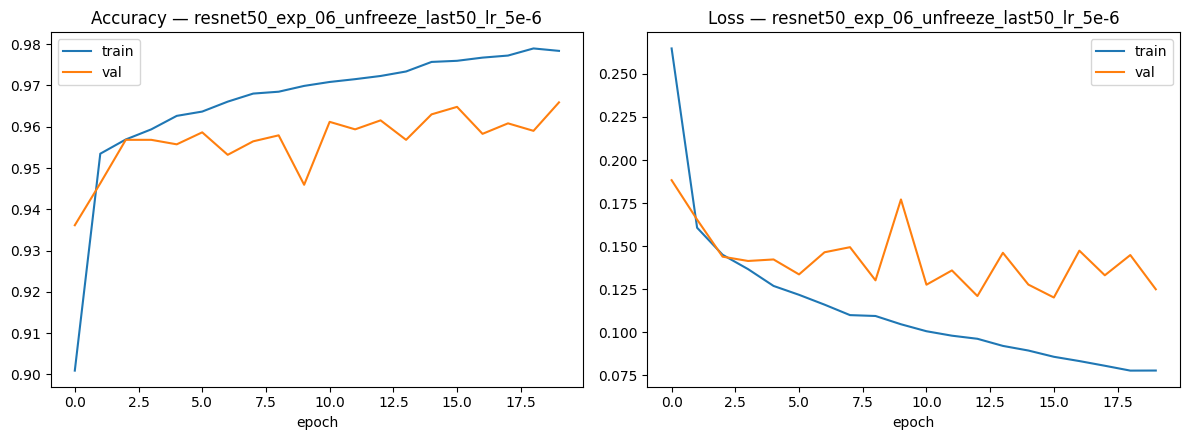

In [ ]:
hist = final["history"]
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(hist["accuracy"], label="train")
axes[0].plot(hist["val_accuracy"], label="val")
axes[0].set_title(f"Accuracy — {final_run_name}"); axes[0].set_xlabel("epoch"); axes[0].legend()

axes[1].plot(hist["loss"], label="train")
axes[1].plot(hist["val_loss"], label="val")
axes[1].set_title(f"Loss — {final_run_name}"); axes[1].set_xlabel("epoch"); axes[1].legend()

plt.tight_layout()
plt.savefig("resnet50_accuracy_loss_curves.png", dpi=200)
plt.show()


**Interpretation:** It is overfitting, not underfitting; the model isn't stalled at a high error; it keeps improving on the training set long after it stops improving on validation. The divergence point is roughly epoch 2–3, which is also right where the initial shared drop ends. After that, training continues to fit the training set more tightly (lower train loss, higher train accuracy) without that improvement transferring to validation, which shows that the gap between the two curves widens for the rest of the run instead of closing.

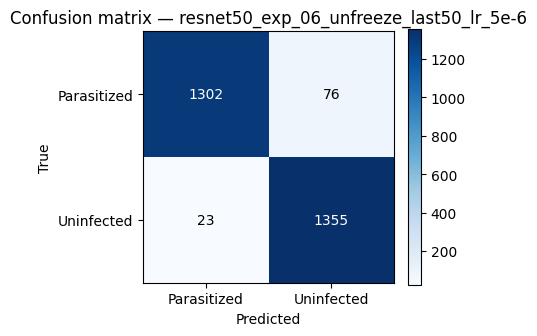

In [ ]:
cm = final["metrics"]["confusion_matrix"]
fig, ax = plt.subplots(figsize=(4.5, 4))
im = ax.imshow(cm, cmap="Blues")
labels = ["Parasitized", "Uninfected"]
ax.set_xticks([0, 1]); ax.set_xticklabels(labels)
ax.set_yticks([0, 1]); ax.set_yticklabels(labels)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — {final_run_name}")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black")
plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.savefig("resnet50_confusion_matrix.png", dpi=200)
plt.show()


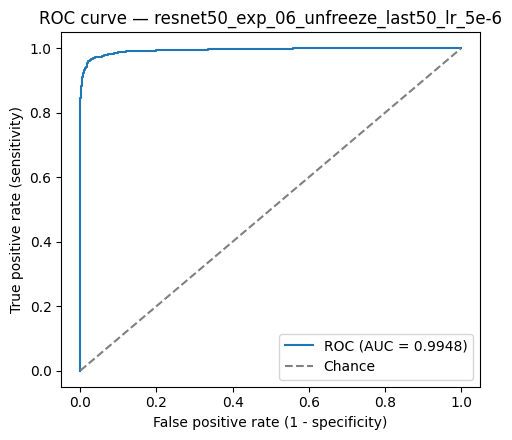

In [ ]:
y_true, y_prob = final["y_true"], final["y_prob"]
# ROC/AUC curve with respect to the 'parasitized' (infected) positive class.
fpr, tpr, _ = roc_curve(1 - y_true, 1 - y_prob)
auc_val = final["metrics"]["roc_auc"]

plt.figure(figsize=(5, 4.5))
plt.plot(fpr, tpr, label=f"ROC (AUC = {auc_val:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Chance")
plt.xlabel("False positive rate (1 - specificity)")
plt.ylabel("True positive rate (sensitivity)")
plt.title(f"ROC curve — {final_run_name}")
plt.legend()
plt.tight_layout()
plt.savefig("resnet50_roc_curve.png", dpi=200)
plt.show()


**Interpretation:** Across training, the accuracy and loss curves track closely for the first 2–3 epochs before diverging; train loss falls steadily to ~0.08 by epoch 19 while val loss plateaus and oscillates between ~0.12 and 0.18, and train accuracy climbs to ~97.8% while val accuracy stalls around 95–96.5%, indicating overfitting rather than underfitting, with the gap widening from roughly epoch 2–3 onward. On the held-out test set, this translates to sensitivity of 94.5% (76 missed infections out of 1,378 parasitized cells) and specificity of 98.3% (23 false alarms out of 1,378 uninfected cells) which is roughly a 3.3:1 ratio of false negatives to false positives, which is the clinically costlier error direction since a missed infection can progress untreated while a false positive only costs an unnecessary confirmatory test.

Against the recommended target of ≥95% sensitivity and ≥90% specificity, specificity clears the bar comfortably but sensitivity falls just short, which is consistent with the overfitting seen in the training curves limiting how well the model generalizes on the minority of harder, borderline infected cases. The ROC curve (AUC = 0.9948) shows strong overall separability, with the default 0.5 threshold sitting near the curve's steep early elbow; given specificity has headroom to spare against its 90% floor, lowering the decision threshold is a concrete way to trade a small amount of specificity for a meaningful sensitivity gain, which is worth proposing as a next step given sensitivity is the clinically prioritized metric here.

## 6. Error analysis

Pull actual misclassified test images for the final model and inspect them.

99 / 2756 test images misclassified (3.59%)


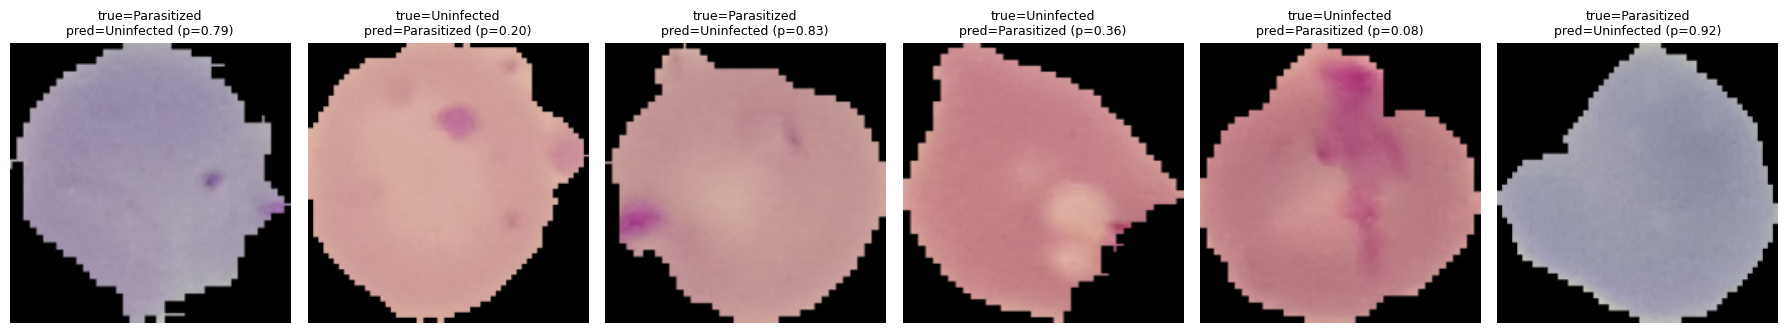

In [ ]:
y_pred = (y_prob >= 0.5).astype(int)
misclassified_idx = np.where(y_pred != y_true)[0]
print(f"{len(misclassified_idx)} / {len(y_true)} test images misclassified "
      f"({len(misclassified_idx)/len(y_true)*100:.2f}%)")

# Re-collect raw (unpreprocessed) test images once so both error analysis and Grad-CAM
# can index into the same array by position.
test_images_raw, test_labels_raw = [], []
for img, lab in ds_test_raw.map(lambda i, l: (tf.image.resize(i, IMG_SIZE), l)):
    test_images_raw.append(img.numpy().astype("uint8") if img.numpy().max() > 1.5 else img.numpy())
    test_labels_raw.append(int(lab.numpy()))
test_images_raw = np.array(test_images_raw)
test_labels_raw = np.array(test_labels_raw)

n_show = min(6, len(misclassified_idx))
fig, axes = plt.subplots(1, n_show, figsize=(3*n_show, 3.2))
if n_show == 1: axes = [axes]
for ax, idx in zip(axes, misclassified_idx[:n_show]):
    ax.imshow(test_images_raw[idx].astype("uint8"))
    true_lab = "Parasitized" if test_labels_raw[idx] == 0 else "Uninfected"
    pred_lab = "Parasitized" if y_pred[idx] == 0 else "Uninfected"
    ax.set_title(f"true={true_lab}\npred={pred_lab} (p={y_prob[idx]:.2f})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("resnet50_misclassified_examples.png", dpi=200)
plt.show()


**Analysis:** Faint, low-contrast false negatives suggest the model misses early-stage/low-density infections, while false positives on heavily or unevenly stained uninfected cells suggest it's partly keying on staining intensity rather than parasite shape alone which is both consistent with a model that's good overall but not yet robust to borderline cases. This lines up with the overfitting seen earlier: the train/val gap widens from exp_05 onward as more layers unfreeze, and widens further in exp_06 versus exp_04, meaning dropout/L2 alone (exp_04, frozen base) controlled overfitting better than fine-tuning plus the same regularization did, so deeper fine-tuning is reintroducing overfitting faster than the current safeguards offset it, and the natural next step is stronger regularization or more aggressive early stopping paired specifically with fine-tuning, not fine-tuning depth by itself.


## 7. Explainability — Grad-CAM

Uses ResNet50's last convolutional block (`conv5_block3_out`) as the target layer.

In [ ]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out"):
    # model here is the full functional model: Input -> base(ResNet50) -> pooling -> ... -> output
    base_model = model.get_layer(index=1)  # the ResNet50 base as passed into build_resnet50_model
    # The base is a nested model, so build the sub-model on the base's own input and push its output
    # through the remaining head layers (avoids the "graph disconnected" error).
    conv_model = tf.keras.Model(
        base_model.input,
        [base_model.get_layer(last_conv_layer_name).output, base_model.output],
    )
    head_layers = model.layers[2:]   # GlobalAveragePooling -> Dense -> (Dropout) -> Dense(sigmoid)
    with tf.GradientTape() as tape:
        conv_out, x = conv_model(img_array, training=False)
        for layer in head_layers:
            x = layer(x, training=False)
        loss = 1 - x[:, 0]   # sigmoid = p(uninfected); 1 - p = 'parasitized' likelihood

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_out = conv_out[0]
    heatmap = conv_out @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(raw_img_uint8, heatmap, alpha=0.4):
    heatmap_resized = tf.image.resize(heatmap[..., np.newaxis], IMG_SIZE).numpy().squeeze()
    cmap = plt.get_cmap("jet")
    colored = cmap(heatmap_resized)[..., :3]
    overlay = (colored * 255 * alpha + raw_img_uint8 * (1 - alpha)).astype("uint8")
    return overlay


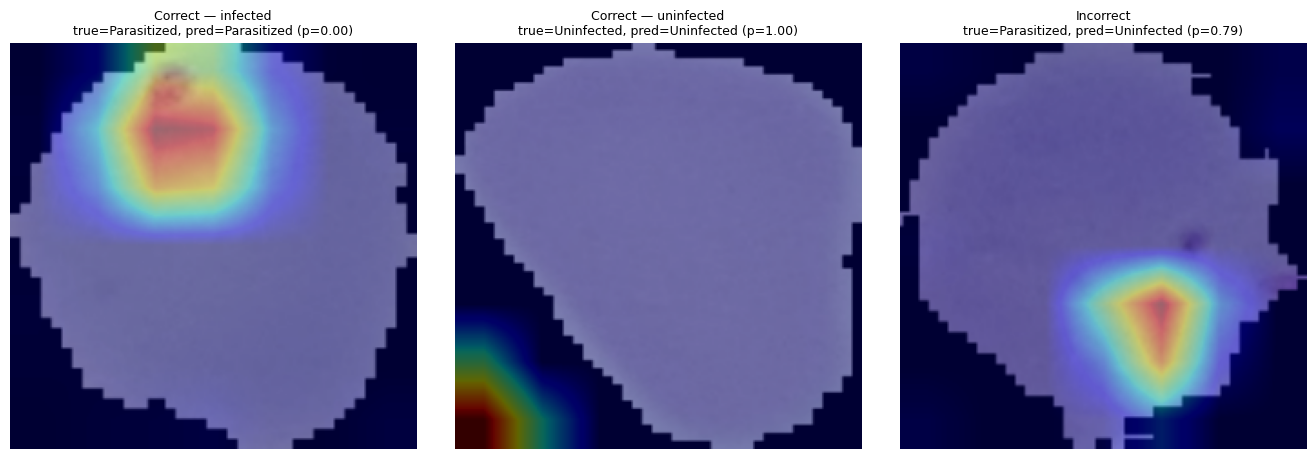

In [ ]:
# Pick one correct-infected, one correct-uninfected, one incorrect example by index.
correct_idx = np.where(y_pred == y_true)[0]
correct_infected_candidates = [i for i in correct_idx if test_labels_raw[i] == 0]
correct_uninfected_candidates = [i for i in correct_idx if test_labels_raw[i] == 1]

pick_infected   = correct_infected_candidates[0]
pick_uninfected = correct_uninfected_candidates[0]
pick_incorrect  = misclassified_idx[0] if len(misclassified_idx) else None

picks = [("Correct — infected", pick_infected),
         ("Correct — uninfected", pick_uninfected)]
if pick_incorrect is not None:
    picks.append(("Incorrect", pick_incorrect))

fig, axes = plt.subplots(1, len(picks), figsize=(4.5*len(picks), 4.5))
for ax, (title, idx) in zip(axes, picks):
    raw = test_images_raw[idx]
    arr = resnet_preprocess(tf.cast(raw, tf.float32)[tf.newaxis, ...])
    heatmap = make_gradcam_heatmap(arr, final["model"])
    overlay = overlay_heatmap(raw, heatmap)
    ax.imshow(overlay)
    ax.set_title(f"{title}\ntrue={'Parasitized' if test_labels_raw[idx]==0 else 'Uninfected'}, "
                 f"pred={'Parasitized' if y_pred[idx]==0 else 'Uninfected'} (p={y_prob[idx]:.2f})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.savefig("resnet50_gradcam_examples.png", dpi=200)
plt.show()


**Interpretation :** The infected example shows attention correctly on the cell body (likely the parasite region), but the uninfected example's strongest activation is on the black background outside the cell. The incorrect example shows confident (p=0.79) attention on a plausible-looking but non-diagnostic edge region, consistent with the faint/early-stage parasitemia pattern from the error analysis.

Overall: inconsistent reasoning which is sometimes cell-focused and medically plausible, but the background activation on the uninfected case is a specific red flag worth noting rather than assuming the model reliably attends to parasite features.